In [ ]:
! pip install numpy
! pip install scikit-learn
! pip install pandas
! pip install seaborn
! pip install matplotlib
! pip install plotly
! pip install --upgrade nbformat

In [ ]:


import numpy as np
from sklearn import datasets
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression
from sklearn import svm
import pandas as pd
import seaborn
import matplotlib.pyplot as plt
import seaborn as sns

# Загрузить таблицу Iris из репозитория UCI (можно из любого доступного источника: UCI, sklearn, kaggle)


In [ ]:
#1 Загрузить таблицу Iris
iris_dataset = datasets.load_iris()

# Поместить данные в объект DataFrame библиотеки pandas.

In [ ]:
#1 Поместить данные в объект DataFrame библиотеки pandas
iris_dataframe = pd.DataFrame(data=iris_dataset.data, columns=iris_dataset.feature_names)
print("5 первый строк")
print(iris_dataframe.head())

5 первый строк
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2


# Вычислить корреляции между признаками на всей таблице и отдельно по классам (использовать pd.groupby).


КОРРЕЛЯЦИЯ НА ВСЕЙ ТАБЛИЦЕ:
                   sepal length (cm)  sepal width (cm)  petal length (cm)  \
sepal length (cm)           1.000000         -0.117570           0.871754   
sepal width (cm)           -0.117570          1.000000          -0.428440   
petal length (cm)           0.871754         -0.428440           1.000000   
petal width (cm)            0.817941         -0.366126           0.962865   

                   petal width (cm)  
sepal length (cm)          0.817941  
sepal width (cm)          -0.366126  
petal length (cm)          0.962865  
petal width (cm)           1.000000  


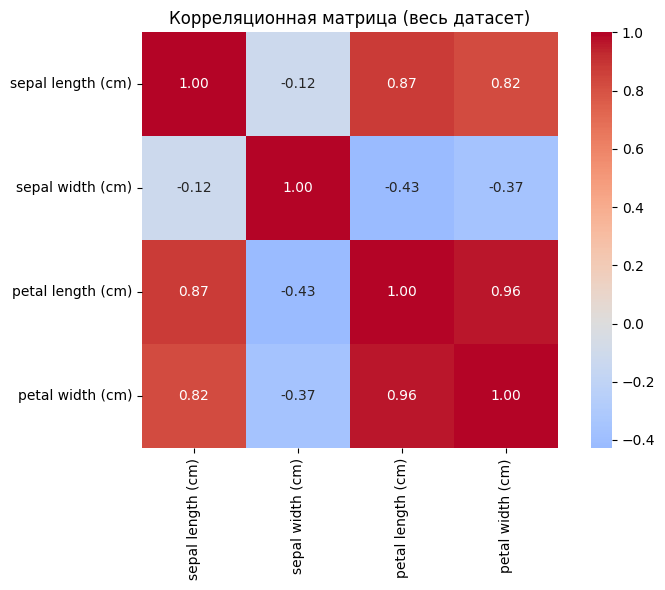

In [ ]:
print("="*50)
print("КОРРЕЛЯЦИЯ НА ВСЕЙ ТАБЛИЦЕ:")
print("="*50)
full_corr = iris_dataframe.corr()
print(full_corr)
# Визуализация
plt.figure(figsize=(8, 6))
sns.heatmap(full_corr, annot=True, cmap='coolwarm', center=0,
            square=True, fmt='.2f')
plt.title('Корреляционная матрица (весь датасет)')
plt.tight_layout()
plt.show()

In [ ]:

print("\n" + "="*50)
print("КОРРЕЛЯЦИЯ ПО КЛАССАМ (с использованием groupby):")
print("="*50)
iris_dataframe['target_num'] = iris_dataset.target
iris_dataframe['species'] = iris_dataset.target_names[iris_dataset.target]
print(iris_dataframe)


КОРРЕЛЯЦИЯ ПО КЛАССАМ (с использованием groupby):
     sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                  5.1               3.5                1.4               0.2   
1                  4.9               3.0                1.4               0.2   
2                  4.7               3.2                1.3               0.2   
3                  4.6               3.1                1.5               0.2   
4                  5.0               3.6                1.4               0.2   
..                 ...               ...                ...               ...   
145                6.7               3.0                5.2               2.3   
146                6.3               2.5                5.0               1.9   
147                6.5               3.0                5.2               2.0   
148                6.2               3.4                5.4               2.3   
149                5.9               3.0                5.

In [ ]:
# Корреляция по числовым меткам
print("\nКорреляция по классам (числовые метки):")
grouped_corr_num = iris_dataframe.groupby('target_num')[iris_dataset.feature_names].corr()
print(grouped_corr_num)

# Корреляция по названиям видов
print("\nКорреляция по классам (названия видов):")
grouped_corr_species = iris_dataframe.groupby('species')[iris_dataset.feature_names].corr()
print(grouped_corr_species)


Корреляция по классам (числовые метки):
                              sepal length (cm)  sepal width (cm)  \
target_num                                                          
0          sepal length (cm)           1.000000          0.742547   
           sepal width (cm)            0.742547          1.000000   
           petal length (cm)           0.267176          0.177700   
           petal width (cm)            0.278098          0.232752   
1          sepal length (cm)           1.000000          0.525911   
           sepal width (cm)            0.525911          1.000000   
           petal length (cm)           0.754049          0.560522   
           petal width (cm)            0.546461          0.663999   
2          sepal length (cm)           1.000000          0.457228   
           sepal width (cm)            0.457228          1.000000   
           petal length (cm)           0.864225          0.401045   
           petal width (cm)            0.281108          0.537

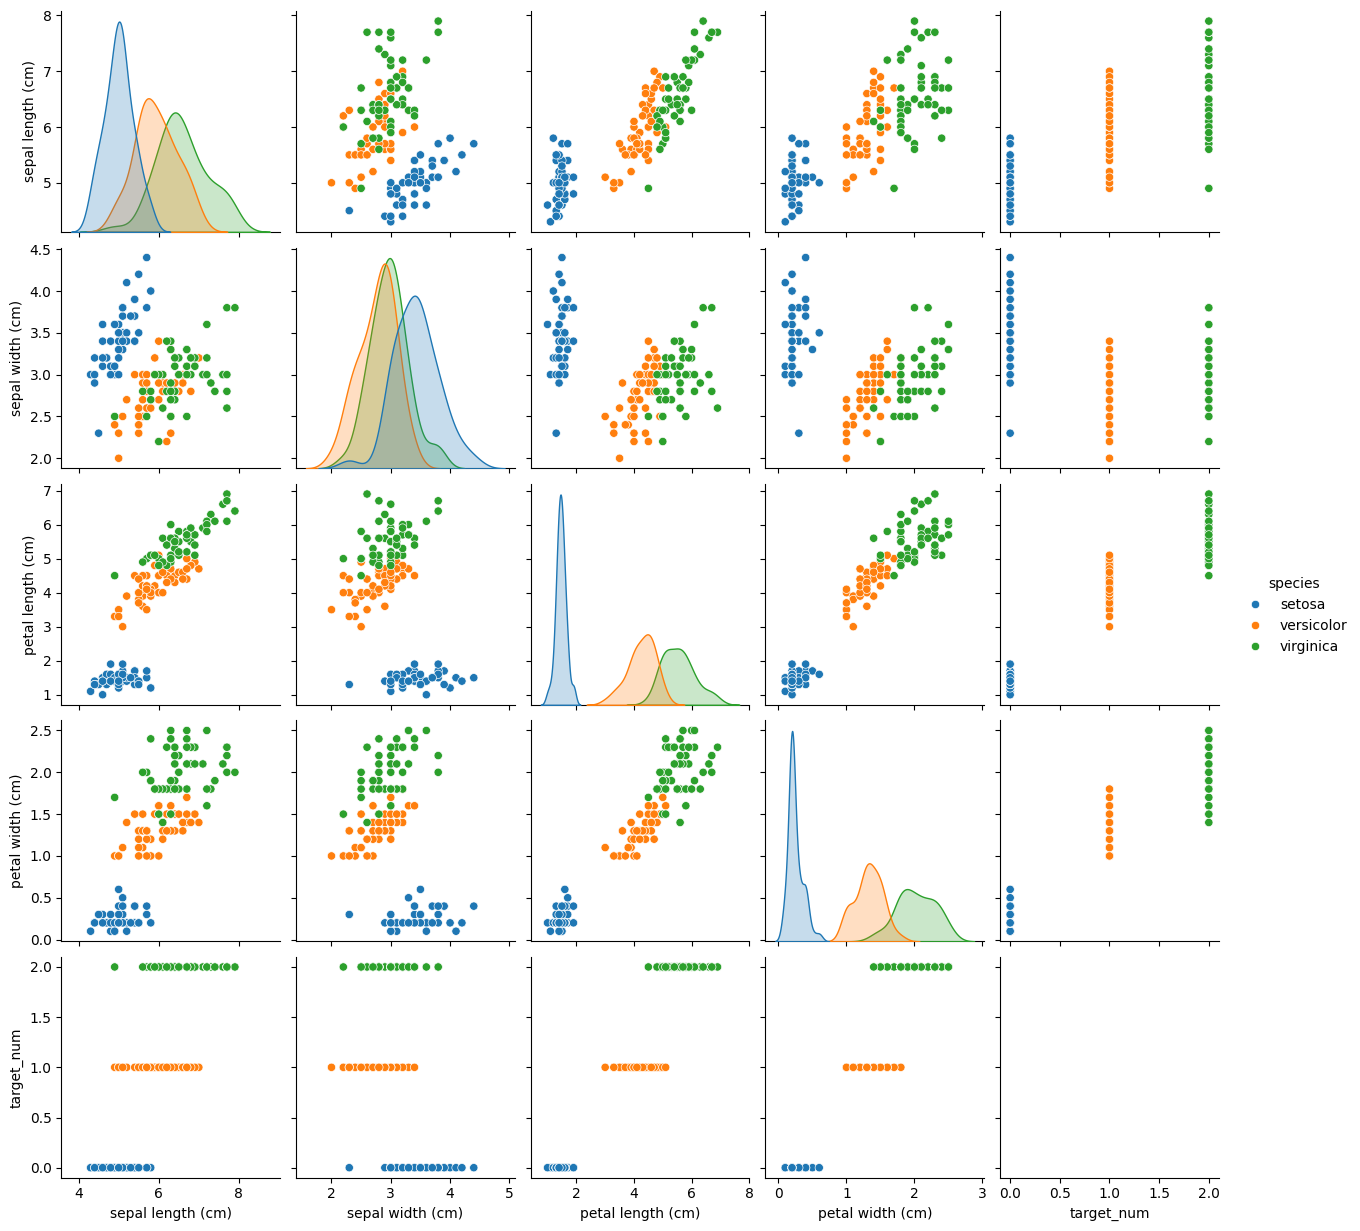

In [ ]:
#1 Визуализировать распределения классов на всех парах переменных
seaborn.pairplot(iris_dataframe, hue='species')

# Выбрать две переменные.

In [ ]:
X = iris_dataset.data[:, [2, 3]]  # Берем 3-й и 4-й признаки (petal length , petal width)(длина и ширина лепестка)

In [ ]:
y = iris_dataset.target

In [ ]:
# Названия признаков для подписей осей
feature_names = [iris_dataset.feature_names[2], iris_dataset.feature_names[3]]
target_names = iris_dataset.target_names

In [ ]:
from sklearn import datasets
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.inspection import DecisionBoundaryDisplay

In [ ]:
# Создаем список классификаторов
classifiers = [
    ('LDA (Линейный дискриминант)', LinearDiscriminantAnalysis()),
    ('QDA (Квадратичный дискриминант)', QuadraticDiscriminantAnalysis()),
    ('Логистическая регрессия', LogisticRegression(max_iter=200)),
    ('SVM с линейным ядром', SVC(kernel='linear', C=1.0)),
    ('SVM с полиномиальным ядром (степень=2)', SVC(kernel='poly', degree=2, C=1.0))
]

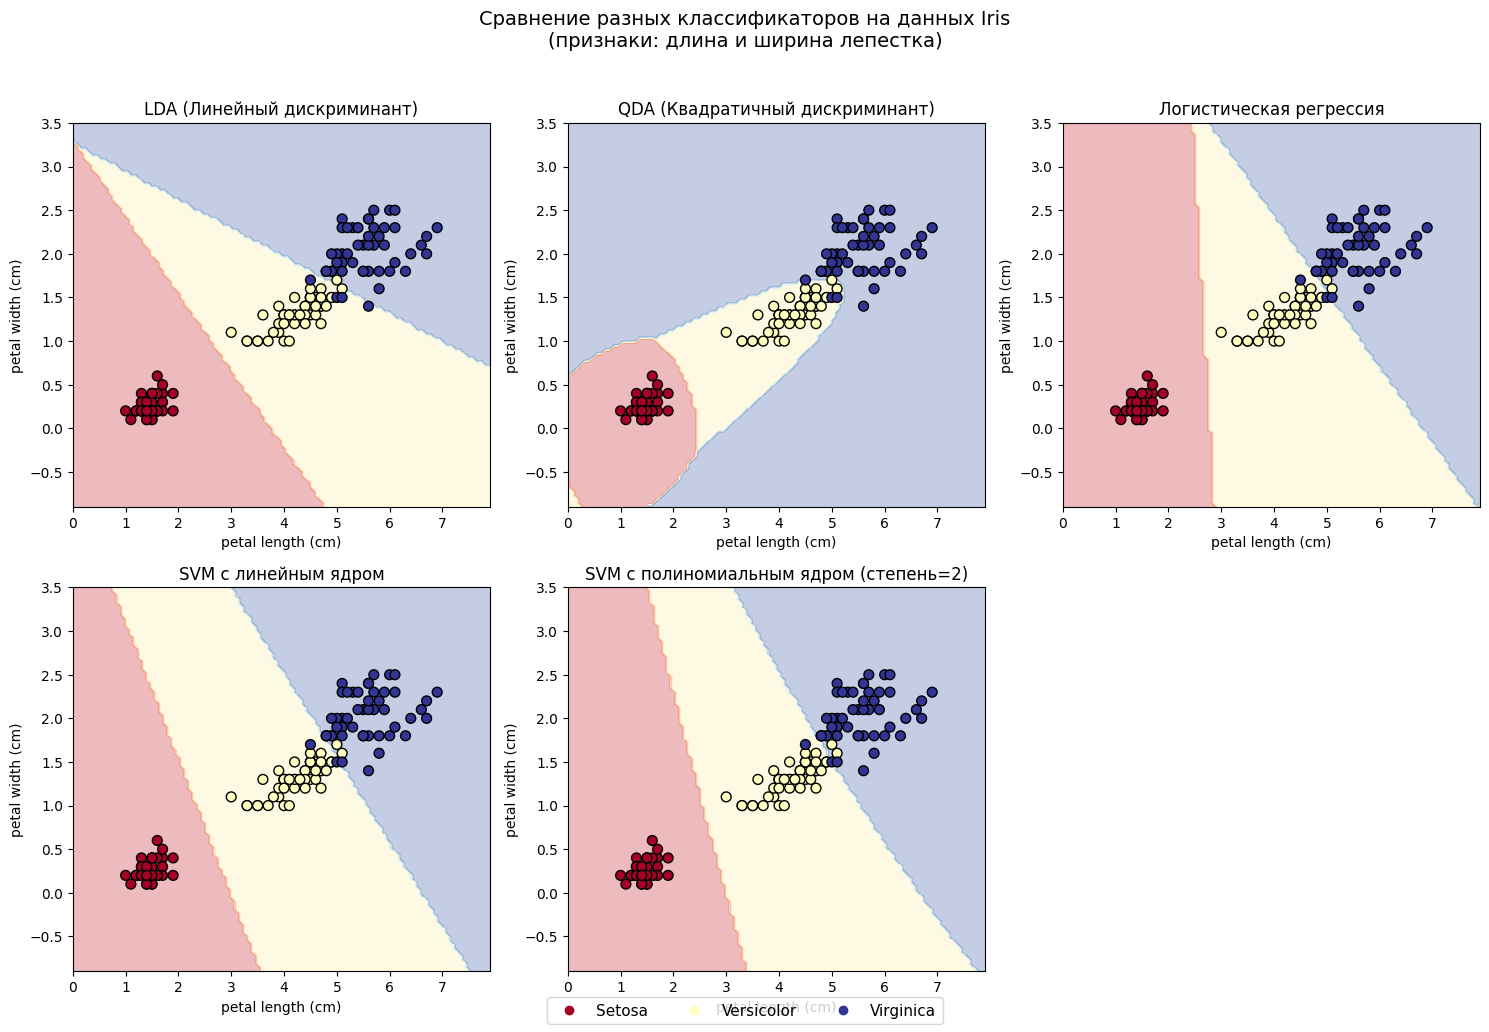

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()  # Преобразуем в плоский список для удобства
# Обучаем и визуализируем каждый классификатор
for idx, (name, clf) in enumerate(classifiers):
    # Обучаем модель
    clf.fit(X, y)

    # Создаем визуализацию разделяющих границ
    disp = DecisionBoundaryDisplay.from_estimator(
        clf, X,
        response_method="predict",
        cmap=plt.cm.RdYlBu,
        alpha=0.3,
        ax=axes[idx],
        xlabel=feature_names[0],
        ylabel=feature_names[1]
    )

    # Добавляем точки данных
    scatter = axes[idx].scatter(X[:, 0], X[:, 1], c=y,
                               cmap=plt.cm.RdYlBu,
                               edgecolors='black',
                               s=50)

    axes[idx].set_title(name, fontsize=12)
    axes[idx].set_xlabel(feature_names[0])
    axes[idx].set_ylabel(feature_names[1])
if len(classifiers) < 6:
    fig.delaxes(axes[5])
handles = scatter.legend_elements()[0]
labels = [name.capitalize() for name in target_names]
fig.legend(handles, labels, loc='lower center', ncol=3, fontsize=11)

plt.suptitle('Сравнение разных классификаторов на данных Iris\n(признаки: длина и ширина лепестка)',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


# В следующих заданиях можно оставить только два (наименее разделимых) класса.
# setosa & virginica

In [ ]:
X = iris_dataset.data  # ВСЕ 4 признака!
y = iris_dataset.target

In [ ]:
# Создаем и обучаем LDA на всех переменных
lda = LinearDiscriminantAnalysis()
lda.fit(X, y)

# Предсказания
y_pred = lda.predict(X)

# Оценка точности
accuracy = lda.score(X, y)
print(f"\nТочность LDA на всех переменных: {accuracy:.4f}")


Точность LDA на всех переменных: 0.9800


# TODO : Добавить отображение ошибочных

In [ ]:
from sklearn.metrics import confusion_matrix
import pandas as pd

# Матрица ошибок
cm = confusion_matrix(y, y_pred)
cm_df = pd.DataFrame(cm,
                     index=[f'истина: {name}' for name in iris_dataset.target_names],
                     columns=[f'предсказано: {name}' for name in iris_dataset.target_names])

print("Матрица ошибок LDA на всех переменных:")
print(cm_df)
print(f"\nТочность: {lda.score(X, y):.3f}")

# Построчная таблица с предсказаниями
results_df = pd.DataFrame({
    'sepal_length': X[:, 0],
    'sepal_width': X[:, 1],
    'petal_length': X[:, 2],
    'petal_width': X[:, 3],
    'true_class': iris_dataset.target_names[y],
    'predicted_class': iris_dataset.target_names[y_pred],
    'correct': y == y_pred
})

print("\nПервые 10 предсказаний:")
print(results_df.head(10))

Матрица ошибок LDA на всех переменных:
                    предсказано: setosa  предсказано: versicolor  \
истина: setosa                       50                        0   
истина: versicolor                    0                       48   
истина: virginica                     0                        1   

                    предсказано: virginica  
истина: setosa                           0  
истина: versicolor                       2  
истина: virginica                       49  

Точность: 0.980

Первые 10 предсказаний:
   sepal_length  sepal_width  petal_length  petal_width true_class  \
0           5.1          3.5           1.4          0.2     setosa   
1           4.9          3.0           1.4          0.2     setosa   
2           4.7          3.2           1.3          0.2     setosa   
3           4.6          3.1           1.5          0.2     setosa   
4           5.0          3.6           1.4          0.2     setosa   
5           5.4          3.9           1.7    

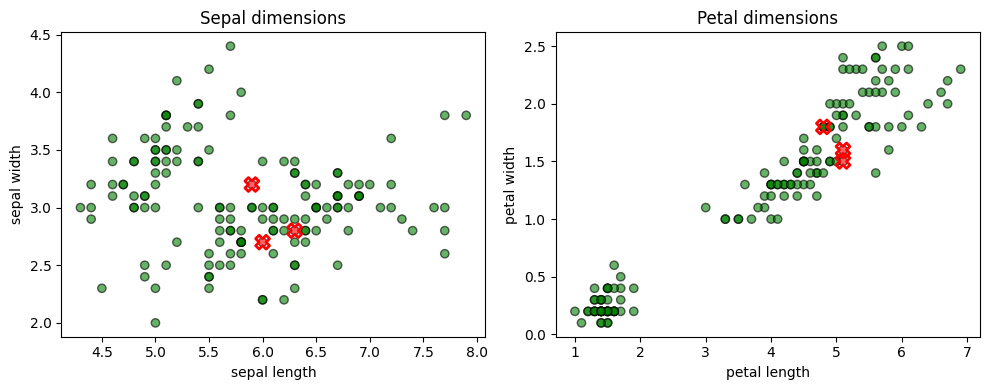

In [ ]:
import matplotlib.pyplot as plt

errors = results_df[~results_df['correct']]

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.scatter(results_df['sepal_length'], results_df['sepal_width'],
            c=results_df['correct'].map({True:'green', False:'red'}),
            alpha=0.6, edgecolors='k')
plt.scatter(errors['sepal_length'], errors['sepal_width'],
            facecolors='none', edgecolors='red', s=100, marker='X', linewidth=2)
plt.xlabel('sepal length')
plt.ylabel('sepal width')
plt.title('Sepal dimensions')

plt.subplot(1,2,2)
plt.scatter(results_df['petal_length'], results_df['petal_width'],
            c=results_df['correct'].map({True:'green', False:'red'}),
            alpha=0.6, edgecolors='k')
plt.scatter(errors['petal_length'], errors['petal_width'],
            facecolors='none', edgecolors='red', s=100, marker='X', linewidth=2)
plt.xlabel('petal length')
plt.ylabel('petal width')
plt.title('Petal dimensions')

plt.tight_layout()
plt.show()

# На двух переменных из п2 вычислить квадратичную разделяющую функцию непосредственно по оценкам ковариационных матриц и средних (самостоятельно реализовать метод, не используя готовый). Визуализировать её и сравнить с решением из п2

In [ ]:
class CustomQDAManual:
    def __init__(self):
        self.classes = None
        self.means = {}  # средние для каждого класса
        self.covariances = {}  # ковариационные матрицы
        self.priors = {}  # априорные вероятности

    def fit(self, X, y):
        """Оценка параметров по обучающей выборке"""
        self.classes = np.unique(y)

        for c in self.classes:
            # Данные текущего класса
            X_c = X[y == c]

            # 1. Средний вектор (центр класса)
            self.means[c] = np.mean(X_c, axis=0)

            # 2. Ковариационная матрица (с поправкой на несмещенность)
            self.covariances[c] = np.cov(X_c.T, bias=False)

            # 3. Априорная вероятность P(y=c)
            self.priors[c] = len(X_c) / len(X)

        return self

    def quadratic_score(self, X, c):
        """Вычисление квадратичной дискриминантной функции для класса c
          Параметры
        ----------
        X : array-like, shape (n_samples, n_features)
            Матрица признаков объектов, для которых вычисляется дискриминантная функция.
            Может быть как одним объектом (1, n_features), так и множеством объектов.

        c : int
            Индекс класса (0, 1, 2 для Iris), для которого вычисляется значение функции.
        Возвращает
        -------
        scores : ndarray, shape (n_samples,)
        Массив значений дискриминантной функции для каждого объекта из X.
        Чем больше значение, тем вероятнее, что объект принадлежит классу c.

        """
        mean = self.means[c]
        cov = self.covariances[c]

        cov_reg = cov + 1e-6 * np.eye(cov.shape[0])

        # Вычисляем три компоненты формулы:

        # 1. -0.5 * ln|Σ|
        _, logdet = np.linalg.slogdet(cov_reg)  # вычисление логарифма определителя
        term1 = -0.5 * logdet

        # 2. -0.5 * (x-μ)^T Σ^{-1} (x-μ)
        diff = X - mean
        inv_cov = np.linalg.inv(cov_reg) # вычисляет обратную матрицу
        term2 = -0.5 * np.sum(diff @ inv_cov * diff, axis=1) # символ @ используется для матричного умножения

        # 3. ln P(k)
        term3 = np.log(self.priors[c])

        return term1 + term2 + term3

    def predict(self, X):
        """Предсказание класса"""
        scores = np.array([self.quadratic_score(X, c) for c in self.classes])
        return self.classes[np.argmax(scores, axis=0)]

    def predict_proba(self, X):
        """Вероятности принадлежности классам"""
        scores = np.array([self.quadratic_score(X, c) for c in self.classes])
        # Нормализация для получения вероятностей
        exp_scores = np.exp(scores - np.max(scores, axis=0, keepdims=True))
        probs = exp_scores / np.sum(exp_scores, axis=0, keepdims=True)
        return probs.T

In [ ]:
X = iris_dataset.data[:, [2, 3]]  # Берем 3-й и 4-й признаки (petal length , petal width)(длина и ширина лепестка)
y = iris_dataset.target
# 1. самодельный QDA
qda_manual = CustomQDAManual()
qda_manual.fit(X, y)
y_pred_manual = qda_manual.predict(X)
accuracy_manual = np.mean(y_pred_manual == y)

# 2. Готовый QDA из sklearn (для сравнения)
qda_sklearn = QuadraticDiscriminantAnalysis()
qda_sklearn.fit(X, y)
y_pred_sklearn = qda_sklearn.predict(X)
accuracy_sklearn = np.mean(y_pred_sklearn == y)


In [ ]:
print("Сравнение точности:")
print(f"Самодельный QDA: {accuracy_manual:.4f}")
print(f"Sklearn QDA:     {accuracy_sklearn:.4f}")
print(f"Совпадение предсказаний: {np.mean(y_pred_manual == y_pred_sklearn):.4f}")

Сравнение точности:
Самодельный QDA: 0.9800
Sklearn QDA:     0.9800
Совпадение предсказаний: 1.0000


In [ ]:
def print_custom_and_qda():
  import matplotlib.pyplot as plt
  import numpy as np

  # Создаем два графика рядом
  fig, axes = plt.subplots(1, 2, figsize=(14, 6))

  # Цвета для классов
  colors = ['red', 'green', 'blue']
  markers = ['o', 's', '^']

  # График 1: Самодельный QDA
  ax = axes[0]
  for i, class_name in enumerate(iris_dataset.target_names):
      mask = y_pred_manual == i
      ax.scatter(X[mask, 0], X[mask, 1],
                c=colors[i], marker='o', s=50, alpha=0.7,
                edgecolors='black', label=f'предсказан {class_name}')
  ax.set_title(f'Самодельный QDA (точность: {accuracy_manual:.3f})')
  ax.set_xlabel(iris_dataset.feature_names[2])
  ax.set_ylabel(iris_dataset.feature_names[3])
  ax.legend()
  ax.grid(True, alpha=0.3)

  # График 2: Sklearn QDA
  ax = axes[1]
  for i, class_name in enumerate(iris_dataset.target_names):
      mask = y_pred_sklearn == i
      ax.scatter(X[mask, 0], X[mask, 1],
                c=colors[i], marker='o', s=50, alpha=0.7,
                edgecolors='black', label=f'предсказан {class_name}')
  ax.set_title(f'Sklearn QDA (точность: {accuracy_sklearn:.3f})')
  ax.set_xlabel(iris_dataset.feature_names[2])
  ax.set_ylabel(iris_dataset.feature_names[3])
  ax.legend()
  ax.grid(True, alpha=0.3)

  plt.tight_layout()
  plt.show()

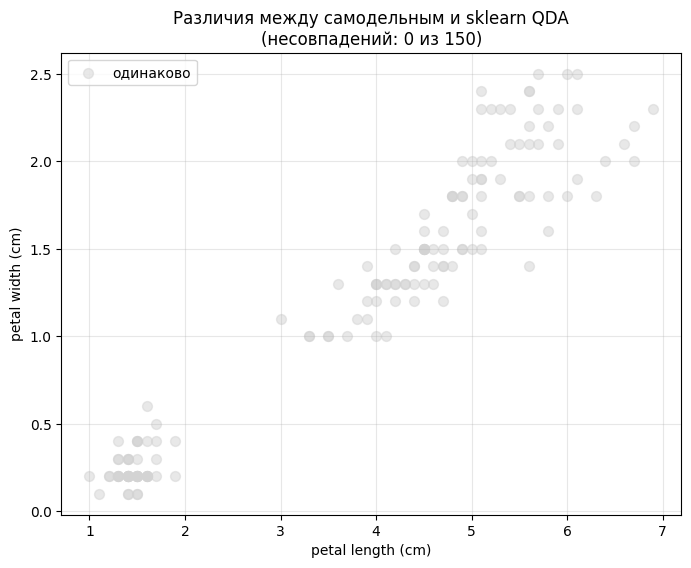

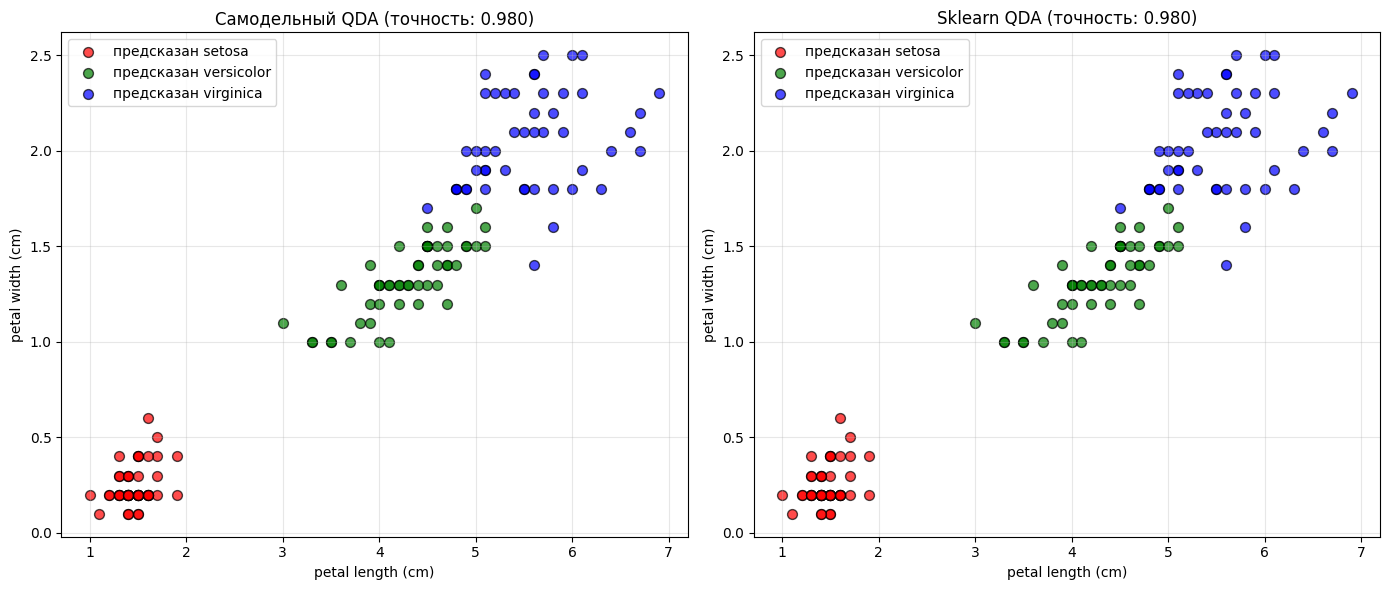

In [ ]:
# График с различиями
plt.figure(figsize=(8, 6))

# Где предсказания совпадают
same = (y_pred_manual == y_pred_sklearn)
plt.scatter(X[same, 0], X[same, 1], c='lightgray', s=50, alpha=0.5, label='одинаково')

# Где различаются
diff = ~same
if np.any(diff):
    plt.scatter(X[diff, 0], X[diff, 1], c='red', s=150, alpha=0.7,
               edgecolors='black', linewidth=2, label='разные предсказания')

plt.xlabel(iris_dataset.feature_names[2])
plt.ylabel(iris_dataset.feature_names[3])
plt.title(f'Различия между самодельным и sklearn QDA\n(несовпадений: {np.sum(diff)} из {len(y)})')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()
print_custom_and_qda()